# Data Preprocessing (LendingClub)

This notebook builds a reproducible preprocessing pipeline for **recovery ratio** prediction using `loan.csv` and the LendingClub data dictionary. Recovery ratio = total_pymnt / loan_amnt.

Outputs:
- `X_train`, `X_val`, `X_test`
- `y_train`, `y_val`, `y_test` (continuous recovery ratios)
- feature names and split summary


## 1) Setup
Set paths and import dependencies.


In [1]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/data/loan.zip' # Corrected path to Google Drive
extract_path = '/content/drive/MyDrive/data/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' successfully unzipped to '{extract_path}'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/data/loan.zip' successfully unzipped to '/content/drive/MyDrive/data/'.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)

RAW_DATA_PATH = Path("/content/drive/MyDrive/data/loan.csv")
DICT_PATH = Path("/content/drive/MyDrive/data/LCDataDictionary.xlsx")


# OUT_DIR = Path("milestone/processed_from_notebook")
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# For quick debugging, set SAMPLE_ROWS to an integer (e.g., 200000).
SAMPLE_ROWS = None

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {RAW_DATA_PATH}")

print("Raw data:", RAW_DATA_PATH)
print("Data dictionary:", DICT_PATH, "(exists:", DICT_PATH.exists(), ")")
# print("Output dir:", OUT_DIR.resolve())

Raw data: /content/drive/MyDrive/data/loan.csv
Data dictionary: /content/drive/MyDrive/data/LCDataDictionary.xlsx (exists: False )


## 2) Load Data

In [3]:
df = pd.read_csv(RAW_DATA_PATH, low_memory=False, nrows=SAMPLE_ROWS)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head(2)

Shape: (2260668, 145)
Columns: 145


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 3) Target Definition and Outcome Filtering
We keep only closed loans (`Fully Paid`, `Charged Off`, `Default`) so we can compute **recovery_ratio = total_pymnt / loan_amnt**. Same scope as 40's default plot. This continuous target measures how much of the loan was recovered. Both `total_pymnt` and `loan_amnt` are used only to build the target and are dropped from X before modeling.

In [4]:
#  closed loans only (Fully Paid + Charged Off + Default)
FINAL_STATUSES = {"Fully Paid", "Charged Off", "Default"}

# Modeling features only (no target-related columns).
# Expanded pre-origination predictors to improve model signal.
SELECTED_FEATURES = [
    "loan_amnt",
    "grade",
    "sub_grade",
    "term",
    "emp_length",
    "annual_inc",
    "int_rate",
    "installment",
    "home_ownership",
    "dti",
    "earliest_cr_line",
    "open_acc",
    "revol_util",
    "verification_status",
    "purpose",
    "addr_state",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec",
    "revol_bal",
    "total_acc",
    "initial_list_status",
    "collections_12_mths_ex_med",
    "application_type",
    "acc_now_delinq",
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",
]
SPLIT_COL = "issue_d"
TARGET_COLS = ["total_pymnt", "loan_amnt"]

available_features = [c for c in SELECTED_FEATURES if c in df.columns]
missing_features = [c for c in SELECTED_FEATURES if c not in df.columns]

if SPLIT_COL not in df.columns:
    raise ValueError(f"Missing required split column: {SPLIT_COL}")
for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f"Missing required column for recovery_ratio: {col}")

if missing_features:
    print("[WARN] Missing requested features in this dataset:", missing_features)

base_cols = list(dict.fromkeys(available_features + [SPLIT_COL] + TARGET_COLS + ["loan_status"]))
base = df[[c for c in base_cols if c in df.columns]].copy()
base = base[base["loan_status"].isin(FINAL_STATUSES)].copy()

# Ensure numeric and valid for division
base["total_pymnt"] = pd.to_numeric(base["total_pymnt"], errors="coerce")
base["loan_amnt"] = pd.to_numeric(base["loan_amnt"], errors="coerce")
base = base[base["loan_amnt"] > 0].copy()
base["recovery_ratio"] = base["total_pymnt"] / base["loan_amnt"]

print("Rows after target filtering:", len(base))
print("Recovery ratio stats: mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    base["recovery_ratio"].mean(), base["recovery_ratio"].min(), base["recovery_ratio"].max()))
print("Included statuses:", FINAL_STATUSES)
print("Requested features:", SELECTED_FEATURES)


Rows after target filtering: 1303638
Recovery ratio stats: mean = 1.0314, min = 0.0000, max = 2.1703
Included statuses: {'Fully Paid', 'Charged Off', 'Default'}
Requested features: ['loan_amnt', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'int_rate', 'installment', 'home_ownership', 'dti', 'earliest_cr_line', 'open_acc', 'revol_util', 'verification_status', 'purpose', 'addr_state', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


## 4) Basic Cleaning

In [5]:
def parse_issue_date(col: pd.Series) -> pd.Series:
    return pd.to_datetime(col, format="%b-%Y", errors="coerce")

def clean_percent(col: pd.Series) -> pd.Series:
    if col.dtype == object:
        return pd.to_numeric(col.astype(str).str.replace("%", "", regex=False), errors="coerce")
    return pd.to_numeric(col, errors="coerce")

def clean_term(col: pd.Series) -> pd.Series:
    return pd.to_numeric(col.astype(str).str.extract(r"(\d+)")[0], errors="coerce")

def clean_emp_length(col: pd.Series) -> pd.Series:
    s = col.astype(str).str.strip().str.lower()
    s = s.replace({"nan": np.nan, "< 1 year": "0", "10+ years": "10"})
    s = s.str.extract(r"(\d+)")[0]
    return pd.to_numeric(s, errors="coerce")

def clean_earliest_cr_line(col: pd.Series) -> pd.Series:
    # Convert 'Apr-2001' to datetime and then to months since the date
    parsed_dates = pd.to_datetime(col, format="%b-%Y", errors="coerce")
    # Calculate months since the earliest credit line relative to a fixed point (e.g., issue_d or a recent date)
    # For simplicity, let's calculate years since 2000 (a common reference point)
    # Or, we can simply return the parsed date and let subsequent steps extract features
    return parsed_dates

work = base.copy()
work["issue_d"] = parse_issue_date(work["issue_d"])

if "term" in work.columns:
    work["term"] = clean_term(work["term"])
if "emp_length" in work.columns:
    work["emp_length"] = clean_emp_length(work["emp_length"])
if "earliest_cr_line" in work.columns:
    work["earliest_cr_line"] = clean_earliest_cr_line(work["earliest_cr_line"])
    # Extract years since earliest credit line
    work['years_since_earliest_cr'] = (work['issue_d'].dt.year - work['earliest_cr_line'].dt.year)
    work.drop(columns=['earliest_cr_line'], inplace=True)

for col in ["total_pymnt", "loan_amnt", "annual_inc", "delinq_2yrs", "inq_last_6mths", "pub_rec",
            "revol_bal", "total_acc", "collections_12_mths_ex_med", "acc_now_delinq", "mort_acc",
            "pub_rec_bankruptcies", "tax_liens", "installment", "dti", "open_acc"]:
    if col in work.columns:
        work[col] = pd.to_numeric(work[col], errors="coerce")

for col in ["int_rate", "revol_util"]:
    if col in work.columns:
        work[col] = clean_percent(work[col])

# grade/sub_grade: ordinal encode for modeling (A=1..G=7, A1=1..G5=35)
grade_order = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
if "grade" in work.columns:
    work["grade"] = work["grade"].map(grade_order)
if "sub_grade" in work.columns:
    work["sub_grade"] = (work["sub_grade"].str[0].map(grade_order).astype(float) - 1) * 5 + pd.to_numeric(work["sub_grade"].str[1], errors="coerce")

print("Shape after feature selection and cleaning:", work.shape)
print(work.head(2))


Shape after feature selection and cleaning: (1303638, 32)
     loan_amnt  grade  sub_grade  term  emp_length  annual_inc  int_rate  \
100      30000      4       20.0    36         5.0    100000.0     22.35   
152      40000      3       14.0    60         0.0     45000.0     16.14   

     installment home_ownership    dti  open_acc  revol_util  \
100      1151.16       MORTGAGE  30.46      11.0        37.0   
152       975.71       MORTGAGE  50.53      18.0        64.5   

    verification_status             purpose addr_state  delinq_2yrs  \
100     Source Verified  debt_consolidation         CA          0.0   
152            Verified         credit_card         OH          0.0   

     inq_last_6mths  pub_rec  revol_bal  total_acc initial_list_status  \
100             0.0      1.0      15603       19.0                   w   
152             0.0      0.0      34971       37.0                   w   

     collections_12_mths_ex_med application_type  acc_now_delinq  mort_acc  \
100  

## 5) EDA for Selected Features
We use an expanded pre-origination feature set (loan attributes, credit history, and borrower/categorical fields) plus `issue_year` and `issue_month` from `issue_d`. Here we do a quick EDA on a compact subset before the train/val/test split:
- Numeric distributions
- Recovery ratio by categorical features
- Correlation heatmap (numeric subset)


EDA shape: (1303638, 8)
EDA columns: ['loan_amnt', 'loan_status', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'recovery_ratio']
Missing ratio (selected features):
emp_length        0.0579
loan_amnt         0.0000
grade             0.0000
loan_status       0.0000
sub_grade         0.0000
term              0.0000
annual_inc        0.0000
recovery_ratio    0.0000
dtype: float64


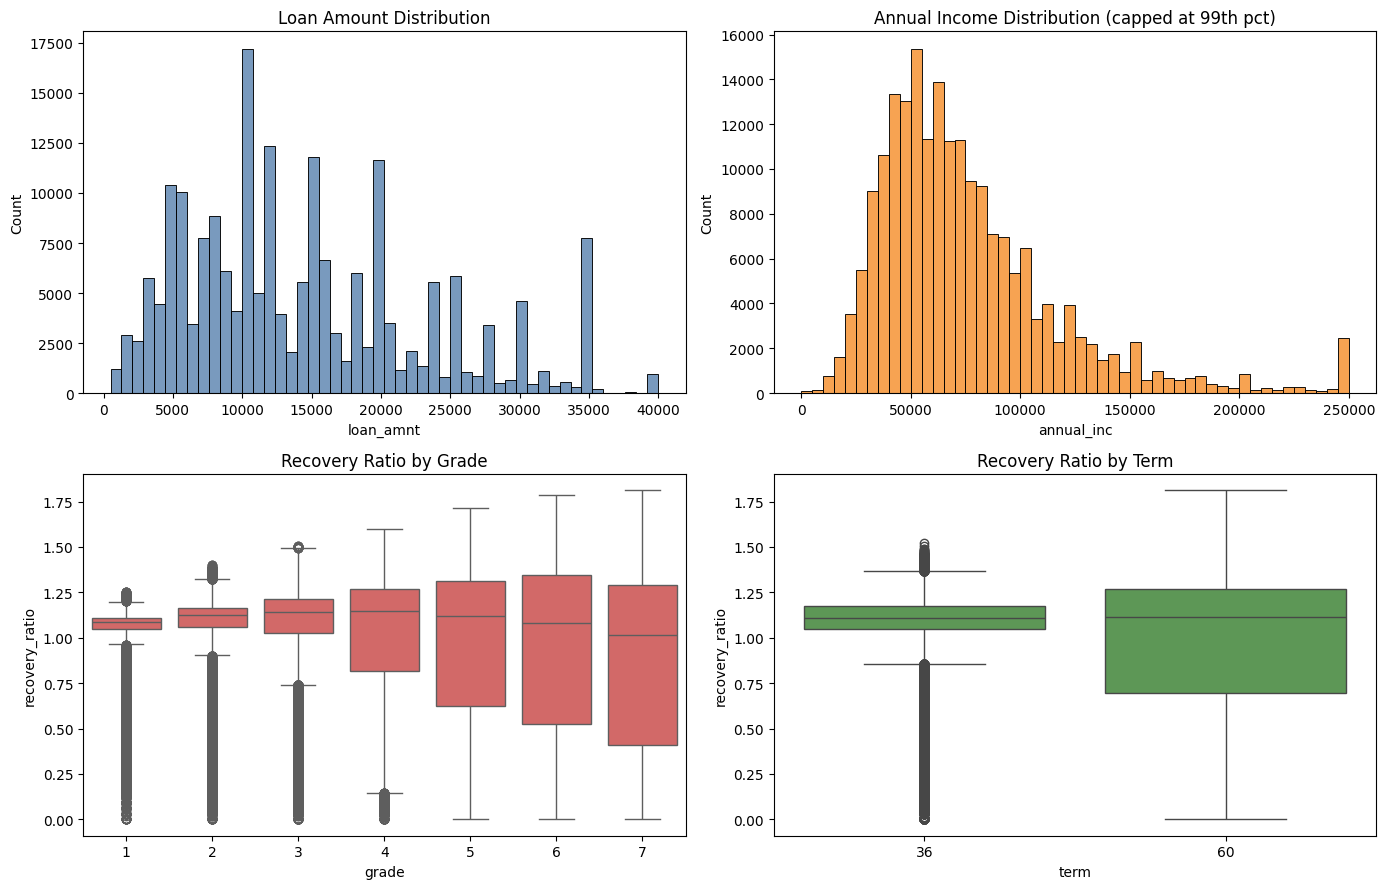


Mean recovery ratio by grade (top 15 rows):


,grade,recovery_ratio
1,2,1.052172
0,1,1.051574
2,3,1.028886
3,4,1.009873
4,5,0.986356
5,6,0.964065
6,7,0.904926



Mean recovery ratio by sub_grade (top 15 rows):


,sub_grade,recovery_ratio
7,8.0,1.058693
6,7.0,1.056631
8,9.0,1.055578
4,5.0,1.054560
2,3.0,1.051956
3,4.0,1.051751
1,2.0,1.049875
0,1.0,1.048000
5,6.0,1.047761
9,10.0,1.042015



Mean recovery ratio by term (top 15 rows):


,term,recovery_ratio
0,36,1.042191
1,60,0.997355



Mean recovery ratio by emp_length (top 15 rows):


,emp_length,recovery_ratio
7,7.0,1.045611
10,10.0,1.041401
6,6.0,1.039193
8,8.0,1.039162
9,9.0,1.034384
5,5.0,1.033578
4,4.0,1.030632
2,2.0,1.028798
3,3.0,1.028119
1,1.0,1.023422


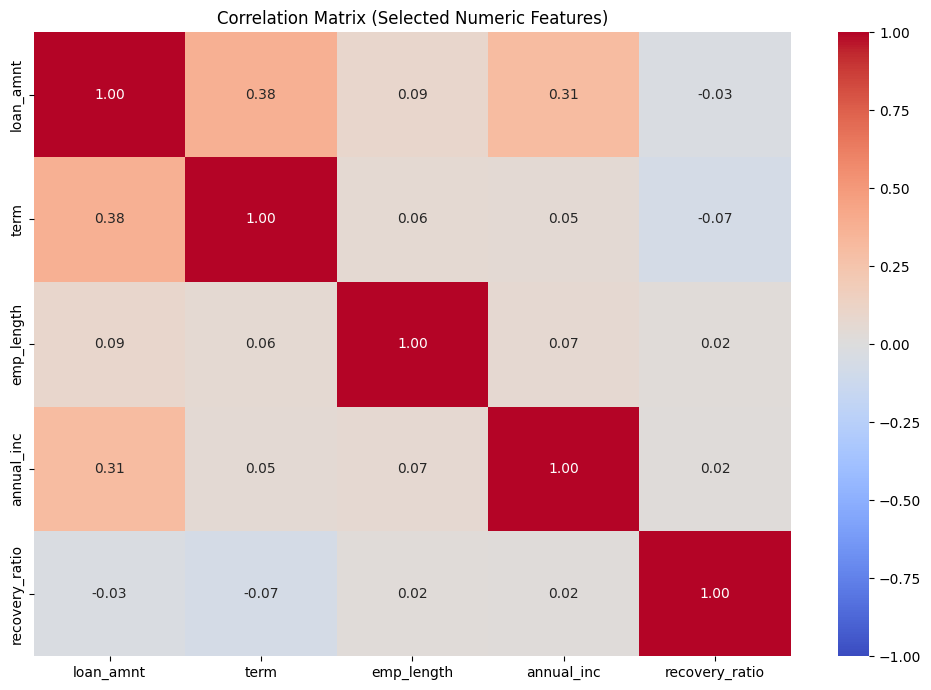

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

requested_eda_cols = [
    "loan_amnt", "loan_status", "grade", "sub_grade", "term",
    "emp_length", "annual_inc", "recovery_ratio"
]
eda_cols = [c for c in requested_eda_cols if c in work.columns]
eda = work[eda_cols].copy()

print("EDA shape:", eda.shape)
print("EDA columns:", eda_cols)
print("Missing ratio (selected features):")
print(eda.isna().mean().sort_values(ascending=False).round(4))

# Keep plotting responsive on full dataset.
EDA_SAMPLE = 200000
plot_df = eda if len(eda) <= EDA_SAMPLE else eda.sample(EDA_SAMPLE, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if "loan_amnt" in plot_df.columns:
    sns.histplot(plot_df["loan_amnt"], bins=50, kde=False, ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].set_title("Loan Amount Distribution")
else:
    axes[0, 0].set_visible(False)

if "annual_inc" in plot_df.columns:
    annual_plot = plot_df["annual_inc"]
    annual_plot = annual_plot.clip(upper=annual_plot.quantile(0.99))
    sns.histplot(annual_plot, bins=50, kde=False, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Annual Income Distribution (capped at 99th pct)")
else:
    axes[0, 1].set_visible(False)

# Recovery ratio by grade and term
if "grade" in plot_df.columns and "recovery_ratio" in plot_df.columns:
    sns.boxplot(data=plot_df, x="grade", y="recovery_ratio", ax=axes[1, 0], color="#e45756")
    axes[1, 0].set_title("Recovery Ratio by Grade")
    axes[1, 0].set_xlabel("grade")
else:
    axes[1, 0].set_visible(False)

if "term" in plot_df.columns and "recovery_ratio" in plot_df.columns:
    sns.boxplot(data=plot_df, x="term", y="recovery_ratio", ax=axes[1, 1], color="#54a24b")
    axes[1, 1].set_title("Recovery Ratio by Term")
    axes[1, 1].set_xlabel("term")
else:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Mean recovery ratio by categorical features.
cat_features = [c for c in ["grade", "sub_grade", "term", "emp_length"] if c in eda.columns]
for col in cat_features:
    if "recovery_ratio" not in eda.columns:
        continue
    tmp = (
        eda[[col, "recovery_ratio"]]
        .dropna()
        .groupby(col, as_index=False)["recovery_ratio"]
        .mean()
        .sort_values("recovery_ratio", ascending=False)
    )
    print(f"\nMean recovery ratio by {col} (top 15 rows):")
    display(tmp.head(15))

# Numeric correlation matrix for selected numeric fields.
num_for_corr_requested = ["loan_amnt", "term", "emp_length", "annual_inc", "recovery_ratio"]
num_for_corr = [c for c in num_for_corr_requested if c in eda.columns]

if len(num_for_corr) >= 2:
    corr = eda[num_for_corr].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Matrix (Selected Numeric Features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")


## 6) Random Train/Val/Test Split (IID)

We **shuffle** rows (`random_state=SEED_SPLIT`) and split **70/15/15** into train/val/test. This **mixes issue dates** across splits (unlike a chronological split). Test metrics are often **more optimistic** than a time-based split; use the latter for forward-looking realism. X excludes `loan_status`, `recovery_ratio`, `total_pymnt`, and `loan_amnt` — only the features go into the model.


In [7]:
MISSING_THRESHOLD = 0.40
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
SEED_SPLIT = 42

from sklearn.model_selection import train_test_split

# Drop high-missing columns first
missing_ratio = work.isna().mean()
high_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
work = work.drop(columns=high_missing, errors="ignore")

work = work[work["issue_d"].notna()].reset_index(drop=True)

y = work["recovery_ratio"].copy()
# avoid data leakage: exclude loan_status, recovery_ratio, total_pymnt, loan_amnt
X = work.drop(columns=["recovery_ratio", "total_pymnt", "loan_amnt", "loan_status"]).copy()

# Random 70/15/15 (IID): shuffles rows so train/val/test share the same vintage mix.
# Metrics are typically more optimistic than a time-ordered split; use for exploration only.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=TRAIN_RATIO, random_state=SEED_SPLIT, shuffle=True
)
val_frac_of_temp = VAL_RATIO / (1.0 - TRAIN_RATIO)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=val_frac_of_temp, random_state=SEED_SPLIT, shuffle=True
)

for frame in [X_train, X_val, X_test]:
    frame["issue_year"] = frame["issue_d"].dt.year
    frame["issue_month"] = frame["issue_d"].dt.month
    frame.drop(columns=["issue_d"], inplace=True)

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "mean_recovery_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
})
summary


,split,rows,mean_recovery_ratio
0,train,912546,1.031517
1,val,195545,1.031138
2,test,195547,1.030858


## 7) ColumnTransformer Preprocessing
- Numeric: median imputation + scaling
- Categorical: most-frequent imputation + one-hot encoding


In [8]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

X_train_arr = preprocessor.fit_transform(X_train)
X_val_arr = preprocessor.transform(X_val)
X_test_arr = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_prep = pd.DataFrame(X_train_arr, columns=feature_names)
X_val_prep = pd.DataFrame(X_val_arr, columns=feature_names)
X_test_prep = pd.DataFrame(X_test_arr, columns=feature_names)

print("Prepared shapes:")
print("X_train:", X_train_prep.shape)
print("X_val:", X_val_prep.shape)
print("X_test:", X_test_prep.shape)

Numeric cols: 23
Categorical cols: 6
Prepared shapes:
X_train: (912546, 101)
X_val: (195545, 101)
X_test: (195547, 101)


## 8) Export Processed Datasets

In [9]:
# Display-only mode: do not write output files.
print("Display-only mode enabled: no files will be written.")

print("\nPrepared dataset shapes:")
print("X_train:", X_train_prep.shape)
print("X_val:", X_val_prep.shape)
print("X_test:", X_test_prep.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nSplit summary:")
display(summary)

feature_df = pd.DataFrame({"feature": feature_names})
print("\nFeature count:", len(feature_df))
print("Feature sample (first 30):")
display(feature_df.head(30))


Display-only mode enabled: no files will be written.

Prepared dataset shapes:
X_train: (912546, 101)
X_val: (195545, 101)
X_test: (195547, 101)
y_train: (912546,)
y_val: (195545,)
y_test: (195547,)

Split summary:


,split,rows,mean_recovery_ratio
0,train,912546,1.031517
1,val,195545,1.031138
2,test,195547,1.030858



Feature count: 101
Feature sample (first 30):


,feature
0,num__grade
1,num__sub_grade
2,num__term
3,num__emp_length
4,num__annual_inc
5,num__int_rate
6,num__installment
7,num__dti
8,num__open_acc
9,num__revol_util


## 9) Notes
- This pipeline is for **recovery ratio prediction** (regression) at/near origination; post-outcome columns are removed.
- Recovery ratio = total_pymnt / loan_amnt (continuous target).
- **Split:** this notebook uses a **random (IID) 70/15/15** split for benchmarking. For **deployment-style** evaluation (later vintages), switch back to sorting by `issue_d` before splitting.
- For modeling, use regression (e.g., Ridge, Random Forest) rather than classification.


## 10) Modeling Benchmarks (Non-Time-Series)

Given the goal is per-loan recovery-ratio prediction (not sequence forecasting), we benchmark:

1. **LinearRegression** (OLS on preprocessed features; linear baseline)
2. **XGBoost** (gradient boosting; fixed hyperparameters from prior tuning)
3. **Side-by-side metrics table** on validation and test sets

Metrics: **MAE**, **RMSE**, **MAPE** / **MdAPE** (mean & median absolute % error on rows with |y|≥0.01; see below), and **R2**.

- **Why MAPE can look very high (not a bug):** `recovery_ratio` spans tiny values (e.g. charged‑off with almost no payback) to ~1+. A fixed absolute error (e.g. 0.2) is a **small %** when y≈1 but a **huge %** when y≈0.02. Mean MAPE averages those, so a minority of low‑recovery loans can dominate. **MdAPE** is less sensitive to that. **MAE/RMSE** on the original scale are usually the fairest headline metrics.


In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 700,
    "max_depth": 4,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
}

if "X_train_prep" not in globals():
    raise RuntimeError("X_train_prep not found. Re-run preprocessing cells before modeling.")

required_expanded_tokens = [
    "num__int_rate",
    "num__dti",
    "cat__home_ownership_RENT",
]
present_feature_names = list(X_train_prep.columns)
missing_tokens = [t for t in required_expanded_tokens if t not in present_feature_names]
print(f"Modeling with {len(present_feature_names)} features (fixed hyperparameters)")
if missing_tokens:
    raise RuntimeError(
        "Expanded features are not reflected in X_train_prep. "
        f"Missing: {missing_tokens}. Re-run from target/cleaning/preprocessing cells."
    )

Xtr = X_train_prep.values
Xva = X_val_prep.values
Xte = X_test_prep.values

ytr = np.asarray(y_train)
yva = np.asarray(y_val)
yte = np.asarray(y_test)


def evaluate_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE / MdAPE: only |y_true| >= 0.01 (1% recovery); tiny y makes relative error meaningless.
    min_abs_y = 0.01
    mask = np.abs(y_true) >= min_abs_y
    if np.any(mask):
        rel = np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))
        mape = float(np.mean(rel) * 100)
        mdape = float(np.median(rel) * 100)
    else:
        mape = float("nan")
        mdape = float("nan")
    return mae, rmse, r2, mape, mdape


linreg = LinearRegression()
linreg.fit(Xtr, ytr)

xgb_model = None
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(**XGB_PARAMS)
    xgb_model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    print("Trained: LinearRegression + XGBRegressor")
except Exception as e:
    print("XGBoost unavailable; LinearRegression only. Reason:", e)

models = {"LinearRegression": linreg}
if xgb_model is not None:
    models["XGBRegressor"] = xgb_model

rows = []
for name, model in models.items():
    pred_val = model.predict(Xva)
    pred_test = model.predict(Xte)

    val_mae, val_rmse, val_r2, val_mape, val_mdape = evaluate_predictions(yva, pred_val)
    test_mae, test_rmse, test_r2, test_mape, test_mdape = evaluate_predictions(yte, pred_test)

    rows.append(
        {
            "model": name,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "val_mape": val_mape,
            "val_mdape": val_mdape,
            "val_r2": val_r2,
            "test_mae": test_mae,
            "test_rmse": test_rmse,
            "test_mape": test_mape,
            "test_mdape": test_mdape,
            "test_r2": test_r2,
        }
    )

results_df = pd.DataFrame(rows).sort_values("test_mae", ascending=True).reset_index(drop=True)

print("\nModel comparison (sorted by test MAE):")
display(results_df)


Modeling with 101 features (fixed hyperparameters)
Trained: LinearRegression + XGBRegressor

Model comparison (sorted by test MAE):


,model,val_mae,val_rmse,val_mape,val_mdape,val_r2,test_mae,test_rmse,test_mape,test_mdape,test_r2
0,XGBRegressor,0.192147,0.277812,43.507545,10.350852,0.098398,0.192663,0.278363,43.754399,10.343526,0.100507
1,LinearRegression,0.200227,0.283774,44.997003,11.592841,0.059282,0.200602,0.284300,45.296029,11.595674,0.061724



Feature importances (XGBoost):


,Feature,Importance
21,issue_year,0.142085
98,cat__initial_list_status_w,0.092789
2,term,0.070551
24,cat__home_ownership_MORTGAGE,0.047082
28,cat__home_ownership_RENT,0.045028
...,...,...
25,cat__home_ownership_NONE,0.000000
54,cat__addr_state_DE,0.000000
58,cat__addr_state_IA,0.000000
91,cat__addr_state_VA,0.000000


/tmp/ipython-input-2835611589.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


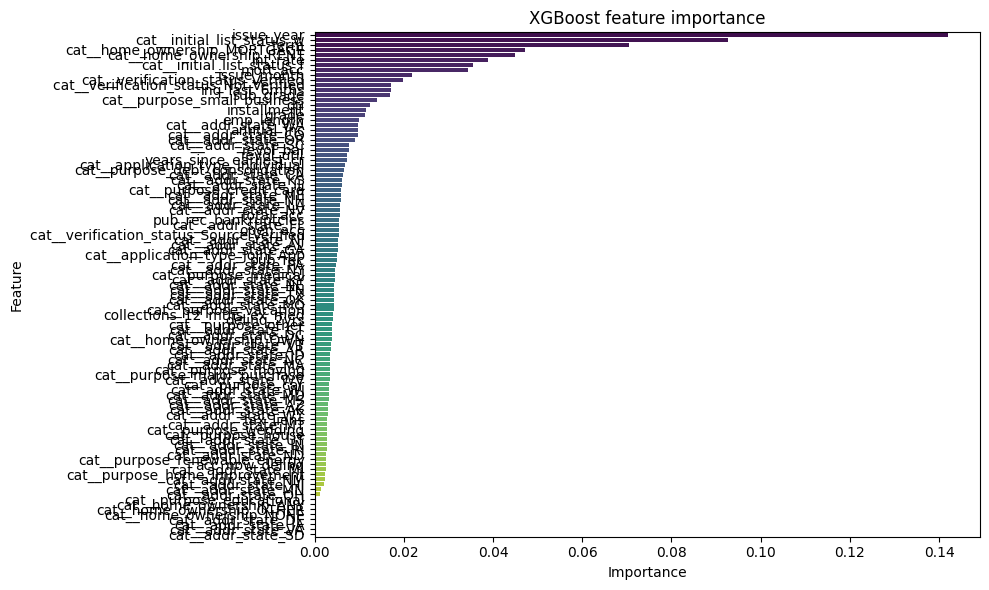

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

if "xgb_model" in globals() and xgb_model is not None:
    xgb_model_obj = xgb_model

    feature_importances = xgb_model_obj.feature_importances_

    original_feature_names = [name.replace("num__", "") for name in feature_names]

    importance_df = pd.DataFrame({
        "Feature": original_feature_names,
        "Importance": feature_importances
    }).sort_values(by="Importance", ascending=False)

    print("\nFeature importances (XGBoost):")
    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
    plt.title("XGBoost feature importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No XGBoost model found. Run the modeling cell above successfully first.")


In [12]:
FINAL_STATUSES = {"Fully Paid", "Charged Off", "Default"}

# Modeling features only (no target-related columns).
SELECTED_FEATURES = [
    "loan_amnt",
    "grade",
    "sub_grade",
    "term",
    "emp_length",
    "annual_inc",
    "int_rate",
    "installment",
    "home_ownership",
    "dti",
    "earliest_cr_line",
    "open_acc",
    "revol_util",
    "verification_status",
    "purpose",
    "addr_state",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec",
    "revol_bal",
    "total_acc",
    "initial_list_status",
    "collections_12_mths_ex_med",
    "application_type",
    "acc_now_delinq",
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",
]
SPLIT_COL = "issue_d"
TARGET_COLS = ["total_pymnt", "loan_amnt"]

available_features = [c for c in SELECTED_FEATURES if c in df.columns]
missing_features = [c for c in SELECTED_FEATURES if c not in df.columns]

if SPLIT_COL not in df.columns:
    raise ValueError(f"Missing required split column: {SPLIT_COL}")
for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f"Missing required column for recovery_ratio: {col}")

if missing_features:
    print("[WARN] Missing requested features in this dataset:", missing_features)

base_cols = list(dict.fromkeys(available_features + [SPLIT_COL] + TARGET_COLS + ["loan_status"])) # Ensure unique and correct order
base = df[[c for c in base_cols if c in df.columns]].copy()
base = base[base["loan_status"].isin(FINAL_STATUSES)].copy()

# Ensure numeric and valid for division
base["total_pymnt"] = pd.to_numeric(base["total_pymnt"], errors="coerce")
base["loan_amnt"] = pd.to_numeric(base["loan_amnt"], errors="coerce")
base = base[base["loan_amnt"] > 0].copy()
base["recovery_ratio"] = base["total_pymnt"] / base["loan_amnt"]

print("Rows after target filtering:", len(base))
print("Recovery ratio stats: mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    base["recovery_ratio"].mean(), base["recovery_ratio"].min(), base["recovery_ratio"].max()))
print("Included statuses:", FINAL_STATUSES)
print("Requested features:", SELECTED_FEATURES)


Rows after target filtering: 1303638
Recovery ratio stats: mean = 1.0314, min = 0.0000, max = 2.1703
Included statuses: {'Fully Paid', 'Charged Off', 'Default'}
Requested features: ['loan_amnt', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'int_rate', 'installment', 'home_ownership', 'dti', 'earliest_cr_line', 'open_acc', 'revol_util', 'verification_status', 'purpose', 'addr_state', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


In [13]:
!pip install catboost

In [14]:
# 11) CatBoost with native categoricals (fixed hyperparameters from prior tuning)

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def _eval_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    min_abs_y = 0.01
    mask = np.abs(y_true) >= min_abs_y
    if np.any(mask):
        rel = np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))
        mape = float(np.mean(rel) * 100)
        mdape = float(np.median(rel) * 100)
    else:
        mape = float("nan")
        mdape = float("nan")
    return mae, rmse, r2, mape, mdape


if "X_train" not in globals() or "X_val" not in globals() or "X_test" not in globals():
    raise RuntimeError("Raw split dataframes not found. Re-run split/preprocessing cells before this cell.")

if "y_train" not in globals() or "y_val" not in globals() or "y_test" not in globals():
    raise RuntimeError("Target splits not found. Re-run split/preprocessing cells before this cell.")

try:
    from catboost import CatBoostRegressor
except Exception as e:
    raise RuntimeError(f"CatBoost is not available in this environment: {e}")

CB_NATIVE = {
    "depth": 10,
    "learning_rate": 0.02,
    "n_estimators": 1500,
    "l2_leaf_reg": 8.0,
    "subsample": 0.8,
}

Xtr_cb = X_train.copy()
Xva_cb = X_val.copy()
Xte_cb = X_test.copy()

ytr_cb = np.asarray(y_train, dtype=np.float32)
yva_cb = np.asarray(y_val, dtype=np.float32)
yte_cb = np.asarray(y_test, dtype=np.float32)

cat_cols_cb = Xtr_cb.select_dtypes(exclude=[np.number]).columns.tolist()

for c in cat_cols_cb:
    Xtr_cb[c] = Xtr_cb[c].astype(str).fillna("__MISSING__")
    Xva_cb[c] = Xva_cb[c].astype(str).fillna("__MISSING__")
    Xte_cb[c] = Xte_cb[c].astype(str).fillna("__MISSING__")

print(f"CatBoost native-categorical: {Xtr_cb.shape[1]} raw features, {len(cat_cols_cb)} cat cols")
print("Fixed config:", CB_NATIVE)

model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    depth=CB_NATIVE["depth"],
    learning_rate=CB_NATIVE["learning_rate"],
    n_estimators=CB_NATIVE["n_estimators"],
    l2_leaf_reg=CB_NATIVE["l2_leaf_reg"],
    subsample=CB_NATIVE["subsample"],
    random_seed=42,
    verbose=False,
)

model.fit(
    Xtr_cb,
    ytr_cb,
    cat_features=cat_cols_cb,
    eval_set=(Xva_cb, yva_cb),
    use_best_model=True,
    early_stopping_rounds=120,
)

pred_val = model.predict(Xva_cb)
pred_test = model.predict(Xte_cb)

val_mae, val_rmse, val_r2, val_mape, val_mdape = _eval_regression(yva_cb, pred_val)
test_mae, test_rmse, test_r2, test_mape, test_mdape = _eval_regression(yte_cb, pred_test)

cb_native_row = {
    "model_name": "CatBoost_native(fixed)",
    "val_mae": val_mae,
    "val_rmse": val_rmse,
    "val_mape": val_mape,
    "val_mdape": val_mdape,
    "val_r2": val_r2,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_mape": test_mape,
    "test_mdape": test_mdape,
    "test_r2": test_r2,
    "best_iteration": int(model.get_best_iteration()),
}

cb_native_df = pd.DataFrame([cb_native_row])
print("\nCatBoost native-cat (fixed config):")
display(cb_native_df)

print(
    "\nMetrics | "
    f"val_mae={val_mae:.6f}, test_mae={test_mae:.6f}, "
    f"test_mape={test_mape:.4f}%, test_mdape={test_mdape:.4f}%, test_r2={test_r2:.6f}, "
    f"best_iteration={cb_native_row['best_iteration']}"
)

best_catboost_native_model = model
best_catboost_native_result = {k: v for k, v in cb_native_row.items()}


CatBoost native-categorical: 29 raw features, 6 cat cols
Fixed config: {'depth': 10, 'learning_rate': 0.02, 'n_estimators': 1500, 'l2_leaf_reg': 8.0, 'subsample': 0.8}

CatBoost native-cat (fixed config):


,model_name,val_mae,val_rmse,val_mape,val_mdape,val_r2,test_mae,test_rmse,test_mape,test_mdape,test_r2,best_iteration
0,CatBoost_native(fixed),0.164149,0.299281,46.325219,4.217026,-0.046338,0.164668,0.299957,46.628406,4.203243,-0.044464,1499



Metrics | val_mae=0.164149, test_mae=0.164668, test_mape=46.6284%, test_mdape=4.2032%, test_r2=-0.044464, best_iteration=1499


## 12) LSTM Monthly Forecast (Integrated)

This section reuses the existing preprocessing artifact `work` (created above) to build a monthly time series and train an LSTM that forecasts next-month cohort mean `recovery_ratio`.


In [15]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# LSTM settings
SEQ_LEN = 12
HIDDEN_SIZE = 24
DROPOUT = 0.25
BATCH_SIZE = 8
LR = 3e-4
MAX_EPOCHS = 220
PATIENCE = 25
USE_LOG1P_TARGET = True
print('TensorFlow:', tf.__version__)


TensorFlow: 2.19.0


In [16]:
if 'work' not in globals():
    raise RuntimeError('`work` not found. Run preprocessing cells above first.')

w = work.copy()
if not np.issubdtype(w['issue_d'].dtype, np.datetime64):
    w['issue_d'] = pd.to_datetime(w['issue_d'], errors='coerce')
w = w[w['issue_d'].notna()].copy()

w['issue_year'] = w['issue_d'].dt.year
w['issue_month'] = w['issue_d'].dt.month

# Candidate loan-level inputs -> monthly cohort features
feature_candidates = [
    'recovery_ratio', 'grade', 'sub_grade', 'term', 'emp_length',
    'annual_inc', 'int_rate', 'dti'
]
available = [c for c in feature_candidates if c in w.columns]
for c in available:
    w[c] = pd.to_numeric(w[c], errors='coerce')

monthly = (
    w.groupby(['issue_year', 'issue_month'])
     .agg(
         mean_recovery_ratio=('recovery_ratio', 'mean'),
         mean_grade=('grade', 'mean') if 'grade' in w.columns else ('recovery_ratio', 'mean'),
         mean_sub_grade=('sub_grade', 'mean') if 'sub_grade' in w.columns else ('recovery_ratio', 'mean'),
         frac_60mo=('term', lambda x: np.mean(x == 60)) if 'term' in w.columns else ('recovery_ratio', 'size'),
         mean_emp_length=('emp_length', 'mean') if 'emp_length' in w.columns else ('recovery_ratio', 'mean'),
         mean_annual_inc=('annual_inc', 'mean') if 'annual_inc' in w.columns else ('recovery_ratio', 'mean'),
         loan_count=('recovery_ratio', 'count'),
     )
     .reset_index()
     .sort_values(['issue_year', 'issue_month'])
     .reset_index(drop=True)
)

monthly['issue_date'] = pd.to_datetime(dict(year=monthly['issue_year'], month=monthly['issue_month'], day=1))
monthly['t_idx'] = np.arange(len(monthly), dtype=float)
monthly['month_sin'] = np.sin(2 * np.pi * monthly['issue_month'] / 12.0)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['issue_month'] / 12.0)
monthly['rr_mom_1m'] = monthly['mean_recovery_ratio'].diff()
monthly['rr_rolling_3m'] = monthly['mean_recovery_ratio'].rolling(3, min_periods=1).mean()

FEATURE_COLS = [
    'mean_recovery_ratio', 'mean_grade', 'mean_sub_grade', 'frac_60mo',
    'mean_emp_length', 'mean_annual_inc', 'loan_count',
    't_idx', 'month_sin', 'month_cos', 'rr_mom_1m', 'rr_rolling_3m'
]
TARGET_COL = 'mean_recovery_ratio'
monthly = monthly.dropna(subset=FEATURE_COLS).reset_index(drop=True)

n = len(monthly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)
train_raw = monthly.iloc[:train_end]
val_raw = monthly.iloc[train_end:val_end]
test_raw = monthly.iloc[val_end:]

feat_scaler = StandardScaler()
train_proc, val_proc, test_proc = train_raw.copy(), val_raw.copy(), test_raw.copy()
if USE_LOG1P_TARGET:
    for d in [train_proc, val_proc, test_proc]:
        d[TARGET_COL] = np.log1p(d[TARGET_COL].clip(lower=0))

feat_scaler.fit(train_proc[FEATURE_COLS])
train_scaled, val_scaled, test_scaled = train_proc.copy(), val_proc.copy(), test_proc.copy()
train_scaled[FEATURE_COLS] = feat_scaler.transform(train_proc[FEATURE_COLS])
val_scaled[FEATURE_COLS] = feat_scaler.transform(val_proc[FEATURE_COLS])
test_scaled[FEATURE_COLS] = feat_scaler.transform(test_proc[FEATURE_COLS])

print(f'Monthly cohorts: {len(monthly)} | Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}')


Monthly cohorts: 138 | Train: 96 | Val: 21 | Test: 21


### Monthly Recovery Trend (Why Time-Series)

This plot shows how the cohort-level mean `recovery_ratio` changes over calendar time, with split boundaries marked. If the level/trend shifts by era, random split can overestimate performance compared with time-based forecasting.


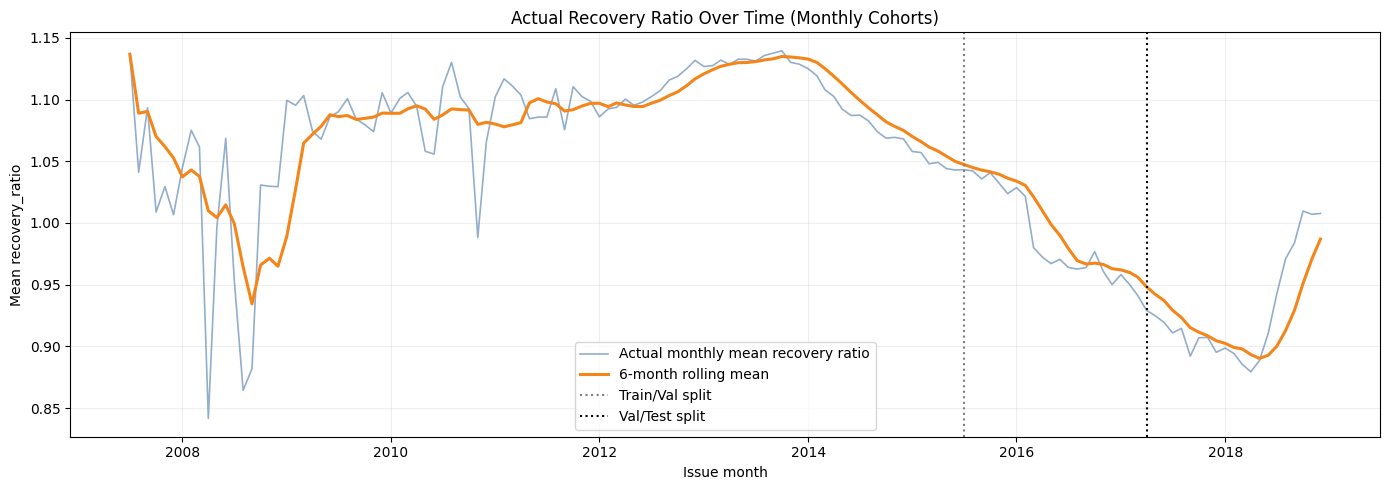

In [17]:
monthly_plot = monthly.copy()
monthly_plot['rr_rolling_6m'] = monthly_plot['mean_recovery_ratio'].rolling(window=6, min_periods=1).mean()

n = len(monthly_plot)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_plot['issue_date'], monthly_plot['mean_recovery_ratio'],
        color='#4c78a8', linewidth=1.2, alpha=0.6, label='Actual monthly mean recovery ratio')
ax.plot(monthly_plot['issue_date'], monthly_plot['rr_rolling_6m'],
        color='#f58518', linewidth=2.2, label='6-month rolling mean')

ax.axvline(monthly_plot['issue_date'].iloc[train_end], color='grey', linestyle=':', linewidth=1.5, label='Train/Val split')
ax.axvline(monthly_plot['issue_date'].iloc[val_end], color='black', linestyle=':', linewidth=1.5, label='Val/Test split')

ax.set_title('Actual Recovery Ratio Over Time (Monthly Cohorts)')
ax.set_xlabel('Issue month')
ax.set_ylabel('Mean recovery_ratio')
ax.grid(alpha=0.2)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [18]:
def build_sequences(context_df, target_df, seq_len, feature_cols, target_col):
    full = pd.concat([context_df, target_df], ignore_index=True)
    feats = full[feature_cols].values.astype(np.float32)
    targets = full[target_col].values.astype(np.float32)
    n_context = len(context_df)
    X, y = [], []
    for i in range(n_context, len(full)):
        if i - seq_len < 0:
            continue
        X.append(feats[i-seq_len:i])
        y.append(targets[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_sequences(train_scaled.iloc[:SEQ_LEN], train_scaled.iloc[SEQ_LEN:], SEQ_LEN, FEATURE_COLS, TARGET_COL)
X_val, y_val = build_sequences(train_scaled.iloc[-SEQ_LEN:], val_scaled, SEQ_LEN, FEATURE_COLS, TARGET_COL)
X_test, y_test = build_sequences(val_scaled.iloc[-SEQ_LEN:], test_scaled, SEQ_LEN, FEATURE_COLS, TARGET_COL)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


X_train: (84, 12, 12) y_train: (84,)
X_val  : (21, 12, 12) y_val  : (21,)
X_test : (21, 12, 12) y_test : (21,)


In [19]:
model_lstm = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, len(FEATURE_COLS))),
    layers.LSTM(HIDDEN_SIZE, return_sequences=False, dropout=DROPOUT),
    layers.Dense(16, activation='relu'),
    layers.Dropout(DROPOUT),
    layers.Dense(1),
], name='LSTM_Integrated')

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
    loss='mae',
    metrics=['mae', 'mse'],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_mae', mode='min', patience=PATIENCE, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', mode='min', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
]

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.7430 - mae: 0.7430 - mse: 1.4779 - val_loss: 1.8249 - val_mae: 1.8249 - val_mse: 3.7156 - learning_rate: 3.0000e-04
Epoch 2/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7454 - mae: 0.7454 - mse: 1.4660 - val_loss: 1.7911 - val_mae: 1.7911 - val_mse: 3.5953 - learning_rate: 3.0000e-04
Epoch 3/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7523 - mae: 0.7523 - mse: 1.4755 - val_loss: 1.7536 - val_mae: 1.7536 - val_mse: 3.4663 - learning_rate: 3.0000e-04
Epoch 4/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7581 - mae: 0.7581 - mse: 1.4796 - val_loss: 1.7280 - val_mae: 1.7280 - val_mse: 3.3787 - learning_rate: 3.0000e-04
Epoch 5/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7323 - mae: 0.7323 - mse: 1.5383 - val_loss: 1.7031 - val_mae: 1.7031 - val_mse: 3.2930 - learning_rate: 3.0000e-04
Epoch 6/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6964 - mae: 0.6964 - mse: 1.2559 - val_loss: 1.6

[Integrated LSTM] Val MAE=0.0301 RMSE=0.0321
[Integrated LSTM] Test MAE=0.0589 RMSE=0.0662


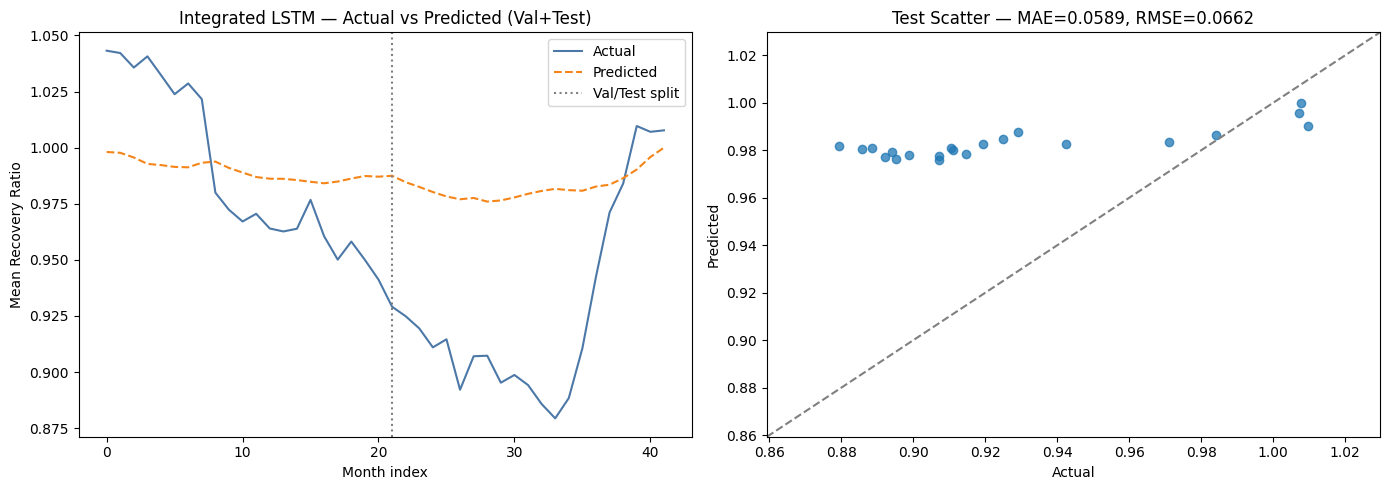

In [20]:
def inv_target(arr_scaled):
    idx = FEATURE_COLS.index(TARGET_COL)
    mean, std = feat_scaler.mean_[idx], feat_scaler.scale_[idx]
    raw = arr_scaled * std + mean
    return np.expm1(raw) if USE_LOG1P_TARGET else raw

v_pred_raw = inv_target(model_lstm.predict(X_val, verbose=0).flatten())
t_pred_raw = inv_target(model_lstm.predict(X_test, verbose=0).flatten())
v_true = inv_target(y_val)
t_true = inv_target(y_test)

# simple validation bias shift
val_bias = float(np.mean(v_pred_raw - v_true))
v_pred = np.clip(v_pred_raw - val_bias, 0.0, None)
t_pred = np.clip(t_pred_raw - val_bias, 0.0, None)

val_mae = mean_absolute_error(v_true, v_pred)
test_mae = mean_absolute_error(t_true, t_pred)
val_rmse = np.sqrt(mean_squared_error(v_true, v_pred))
test_rmse = np.sqrt(mean_squared_error(t_true, t_pred))

print(f'[Integrated LSTM] Val MAE={val_mae:.4f} RMSE={val_rmse:.4f}')
print(f'[Integrated LSTM] Test MAE={test_mae:.4f} RMSE={test_rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_true = np.concatenate([v_true, t_true])
all_pred = np.concatenate([v_pred, t_pred])
x = np.arange(len(all_true))
axes[0].plot(x, all_true, label='Actual', color='#4c78a8')
axes[0].plot(x, all_pred, '--', label='Predicted', color='#f58518')
axes[0].axvline(len(v_true), color='grey', linestyle=':', label='Val/Test split')
axes[0].set_title('Integrated LSTM — Actual vs Predicted (Val+Test)')
axes[0].set_xlabel('Month index')
axes[0].set_ylabel('Mean Recovery Ratio')
axes[0].legend()

axes[1].scatter(t_true, t_pred, alpha=0.75)
lim0 = min(t_true.min(), t_pred.min()) - 0.02
lim1 = max(t_true.max(), t_pred.max()) + 0.02
axes[1].plot([lim0, lim1], [lim0, lim1], '--', color='grey')
axes[1].set_xlim([lim0, lim1]); axes[1].set_ylim([lim0, lim1])
axes[1].set_title(f'Test Scatter — MAE={test_mae:.4f}, RMSE={test_rmse:.4f}')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
plt.tight_layout(); plt.show()


## 13) Loan-Level LSTM (Time-Based Split, Same as Preprocessing Notebook)

This section uses the **exact time-based split code** from `Data_preprocessing_code.ipynb`, then fits an LSTM on loan-level rows for comparison.


In [21]:
MISSING_THRESHOLD = 0.40
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Drop high-missing columns first
missing_ratio = work.isna().mean()
high_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
work = work.drop(columns=high_missing, errors="ignore")

work = work[work["issue_d"].notna()].sort_values("issue_d").reset_index(drop=True)

y = work["recovery_ratio"].copy()
# avoid data leakage: exclude loan_status, recovery_ratio, total_pymnt, loan_amnt
X = work.drop(columns=["recovery_ratio", "total_pymnt", "loan_amnt", "loan_status"]).copy()

n = len(X)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

for frame in [X_train, X_val, X_test]:
    frame["issue_year"] = frame["issue_d"].dt.year
    frame["issue_month"] = frame["issue_d"].dt.month
    frame.drop(columns=["issue_d"], inplace=True)

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "mean_recovery_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
})
summary


,split,rows,mean_recovery_ratio
0,train,912546,1.069674
1,val,195546,0.965451
2,test,195546,0.918483


In [22]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Build loan-level preprocessing on this split
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor_ll = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

Xtr_arr = preprocessor_ll.fit_transform(X_train)
Xva_arr = preprocessor_ll.transform(X_val)
Xte_arr = preprocessor_ll.transform(X_test)

# LSTM expects 3D: (samples, timesteps, features).
# For loan-level rows (no natural sequence), use a single timestep per loan.
Xtr_lstm = Xtr_arr[:, np.newaxis, :].astype(np.float32)
Xva_lstm = Xva_arr[:, np.newaxis, :].astype(np.float32)
Xte_lstm = Xte_arr[:, np.newaxis, :].astype(np.float32)

ytr = np.asarray(y_train, dtype=np.float32)
yva = np.asarray(y_val, dtype=np.float32)
yte = np.asarray(y_test, dtype=np.float32)

print("Loan-level LSTM shapes:")
print("Xtr_lstm:", Xtr_lstm.shape, "Xva_lstm:", Xva_lstm.shape, "Xte_lstm:", Xte_lstm.shape)


Loan-level LSTM shapes:
Xtr_lstm: (912546, 1, 101) Xva_lstm: (195546, 1, 101) Xte_lstm: (195546, 1, 101)


In [23]:
loan_lstm = keras.Sequential([
    keras.Input(shape=(1, Xtr_lstm.shape[2])),
    layers.LSTM(32, return_sequences=False, dropout=0.2),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1),
], name="LoanLevel_LSTM")

loan_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss="mae",
    metrics=["mae", "mse"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_mae", mode="min", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

hist_ll = loan_lstm.fit(
    Xtr_lstm, ytr,
    validation_data=(Xva_lstm, yva),
    epochs=60,
    batch_size=512,
    shuffle=False,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.3527 - mae: 0.3527 - mse: 0.2173 - val_loss: 0.2062 - val_mae: 0.2062 - val_mse: 0.0966 - learning_rate: 3.0000e-04
Epoch 2/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.2071 - mae: 0.2071 - mse: 0.0920 - val_loss: 0.1995 - val_mae: 0.1995 - val_mse: 0.1016 - learning_rate: 3.0000e-04
Epoch 3/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1765 - mae: 0.1765 - mse: 0.0812 - val_loss: 0.1982 - val_mae: 0.1982 - val_mse: 0.1068 - learning_rate: 3.0000e-04
Epoch 4/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1566 - mae: 0.1566 - mse: 0.0782 - val_loss: 0.1982 - val_mae: 0.1982 - val_mse: 0.1075 - learning_rate: 3.0000e-04
Epoch 5/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1520 - mae: 0.1520 - mse: 0.0782 - val_loss: 0.1980 - val_mae: 0.1980 - val_mse: 0.1073 - learning_rate: 3.0000e-04
Epoch 6/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1514 - mae: 0.1514 - mse: 0.0781 -

In [24]:
pred_val = loan_lstm.predict(Xva_lstm, verbose=0).flatten()
pred_test = loan_lstm.predict(Xte_lstm, verbose=0).flatten()

val_mae_ll = mean_absolute_error(yva, pred_val)
val_rmse_ll = np.sqrt(mean_squared_error(yva, pred_val))
test_mae_ll = mean_absolute_error(yte, pred_test)
test_rmse_ll = np.sqrt(mean_squared_error(yte, pred_test))
test_bias_ll = float(np.mean(pred_test - yte))

print(f"Loan-level LSTM | Val MAE={val_mae_ll:.4f} RMSE={val_rmse_ll:.4f}")
print(f"Loan-level LSTM | Test MAE={test_mae_ll:.4f} RMSE={test_rmse_ll:.4f} bias={test_bias_ll:+.4f}")


Loan-level LSTM | Val MAE=0.1980 RMSE=0.3275
Loan-level LSTM | Test MAE=0.2060 RMSE=0.3683 bias=+0.1679
